In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [114]:
df=pd.read_csv('height-weight.csv')

In [115]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [116]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

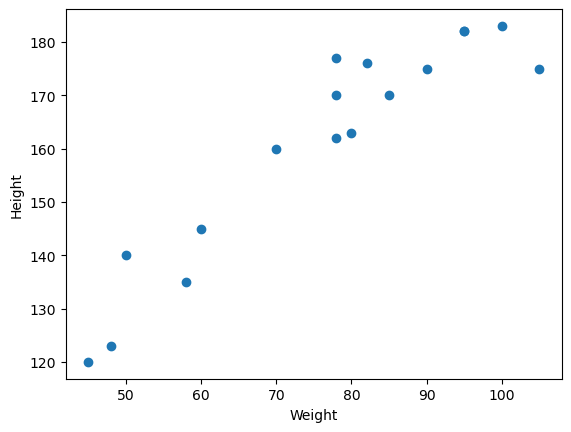

In [117]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")


In [118]:
#divide dataset in independent and dependent features
X=df[['Weight']]#independent 
y=df['Height']#dependent


In [119]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42)


In [120]:
X.shape

(17, 1)

In [121]:
X_train.shape

(12, 1)

In [122]:
X_test.shape

(5, 1)

In [123]:
#standardization for independent feature
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [124]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

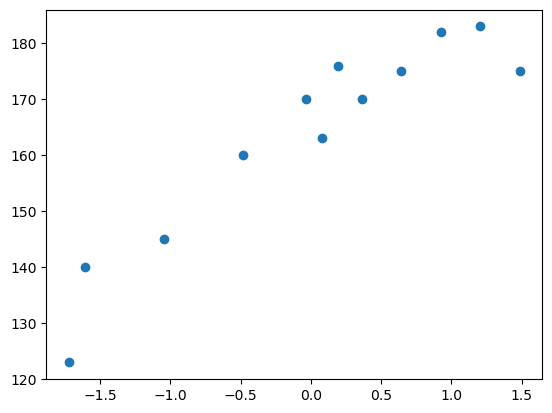

In [125]:
plt.scatter(X_train,y_train)

In [126]:
#train our model SLR model
from sklearn.linear_model import LinearRegression
linreg=LinearRegression()


In [127]:
linreg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
linreg.coef_#slope or coef
linreg.intercept_

np.float64(163.5)

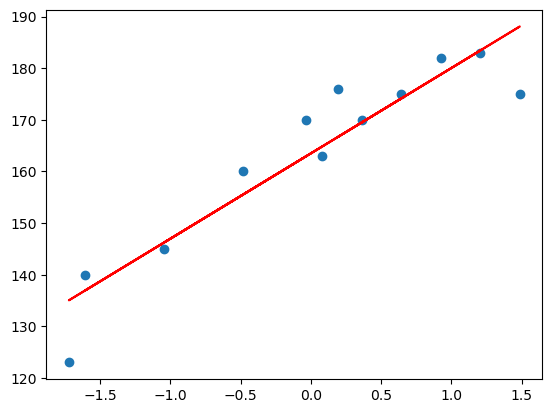

In [129]:
plt.scatter(X_train,y_train)
plt.plot(X_train,linreg.predict(X_train),'r')

In [130]:
y_pred=linreg.predict(X_test)

In [131]:
y_pred,y_test

(array([132.24630466, 144.34450931, 162.95713184, 162.95713184,
        178.777861  ]),
 0     120
 1     135
 5     162
 15    177
 11    182
 Name: Height, dtype: int64)

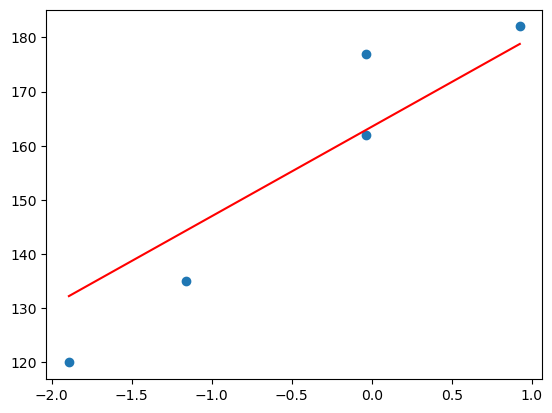

In [132]:
plt.scatter(X_test,y_test)
plt.plot(X_test,linreg.predict(X_test),'r')

In [134]:
#mae,mse,r2
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

89.15845183836954
7.962590593677726
9.442375328187794


In [135]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)

In [136]:
score

0.8455756341998588

In [138]:
#adjusted r square
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7941008455998118

In [139]:
linreg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [141]:
#PREDICTION FOR NEW VALUE suppose weight=90
scaled_weight=scaler.transform([[90]])
scaled_weight


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.64300827]])

In [144]:
scaled_weight[0]

array([0.64300827])

In [143]:
linreg.predict([scaled_weight[0]])

array([174.12470536])

In [145]:
print("the predicted height for 90 kg is",linreg.predict([scaled_weight[0]]))

the predicted height for 90 kg is [174.12470536]


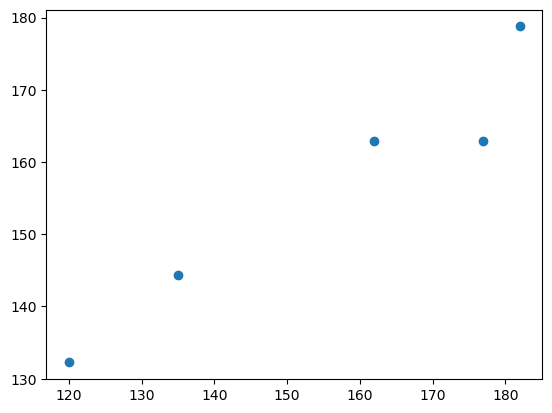

In [ ]:
plt.scatter(y_test,y_pred)
#good model if points are linear

In [147]:
#residuals
residuals=y_test-y_pred

In [148]:
residuals

0    -12.246305
1     -9.344509
5     -0.957132
15    14.042868
11     3.222139
Name: Height, dtype: float64

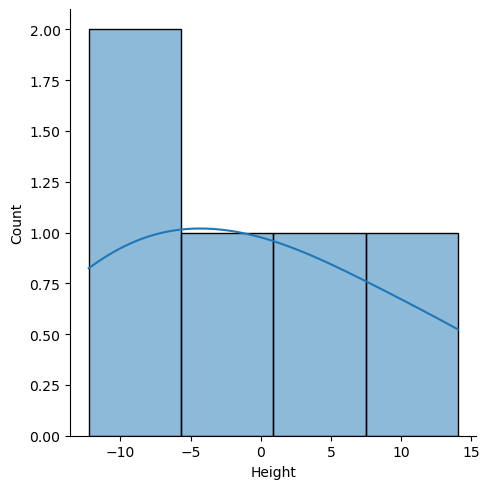

In [ ]:
sns.displot(residuals,kde=True)
#good model if is skewed

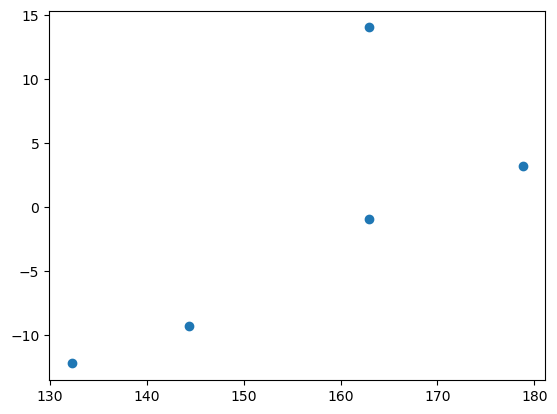

In [ ]:
plt.scatter(y_pred,residuals)
#Good model if has uniform distributuin here